In [2]:
import torch
from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer, EsmForMaskedLM
from tokenizers import Tokenizer
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle

from scipy.spatial.distance import jensenshannon
from scipy.stats import chi2
from collections import Counter

/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
with open('/Users/johnhutchens/Desktop/Practicum/Data/Wild_Dictionaries/pg2_ProGym_matrices.pickle',
           'rb') as f:
    pg_dict = pickle.load(f)

In [9]:
keys= list(pg_dict.keys())

In [12]:
unif_dist = np.ones(20)/20
js_from_unif = []

k = keys[52]
log_probs = pg_dict[k]['log_probs']

for i in range(len(log_probs)):
    prob_dist = np.exp(log_probs[i])
    js = jensenshannon(prob_dist, unif_dist)
    js_from_unif.append(js)

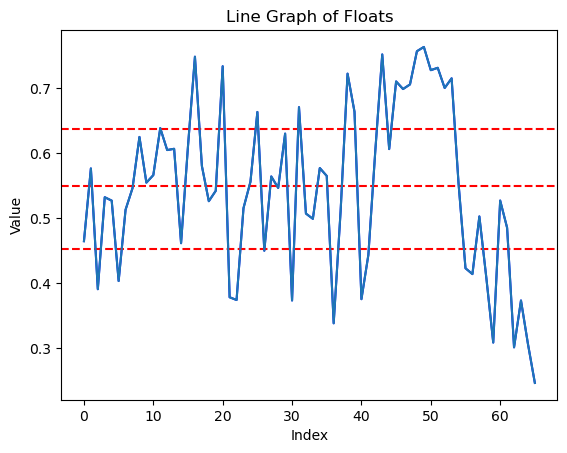

In [19]:
values = js_from_unif

q1 = np.percentile(values, 25)
q2 = np.percentile(values, 50)  # median
q3 = np.percentile(values, 75)

# Plot the line graph
plt.plot(values, color='blue')

# Plot quartiles as horizontal lines
plt.axhline(q1, color='red', linestyle='--', label='Q1 (25th)')
plt.axhline(q2, color='red', linestyle='--', label='Median (50th)')
plt.axhline(q3, color='red', linestyle='--', label='Q3 (75th)')

plt.plot(values)  
plt.title("Line Graph of Floats")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(False)
plt.show()